In [0]:
#/Volumes/workspace/default/bike_sharing/day.csv
#/Volumes/workspace/default/bike_sharing/hour.csv

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [0]:
day_data = pd.read_csv('/Volumes/workspace/default/bike_sharing/day.csv')
day_data.head(2)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801


In [0]:
hour_df = pd.read_csv('/Volumes/workspace/default/bike_sharing/hour.csv')

In [0]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [0]:
day_data.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [0]:
year_map = {0:2011, 1:2012}
day_data['yr'] = day_data['yr'].map(year_map)
day_df = day_data.rename(columns={'yr':'year'})

In [0]:
# 3. Data cleaning and preprocessing
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [0]:
# Categorical variables
day_df['season'] = day_df['season'].astype('category')
day_df['weathersit'] = day_df['weathersit'].astype('category')
day_df['weekday'] = day_df['weekday'].astype('category')
day_df['mnth'] = day_df['mnth'].astype('category')

In [0]:
print("\nMissing values:")
print(day_df.isnull().sum())


Missing values:
instant       0
dteday        0
season        0
year          0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


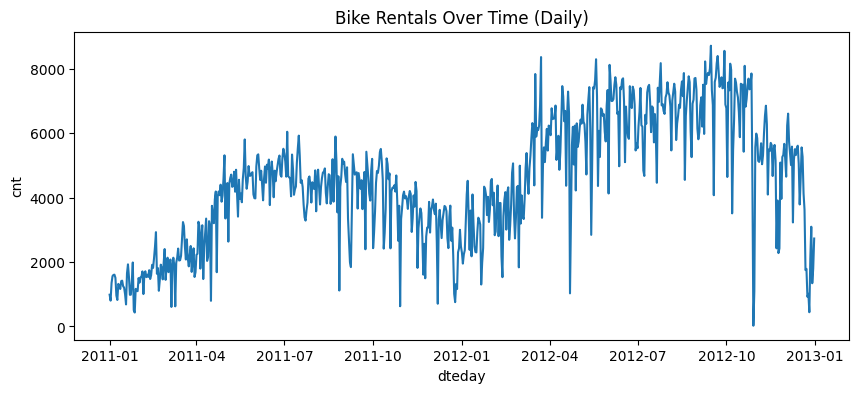

In [0]:
plt.figure(figsize=(10,4))
sns.lineplot(x="dteday", y="cnt", data=day_df)
plt.title("Bike Rentals Over Time (Daily)")
plt.show()

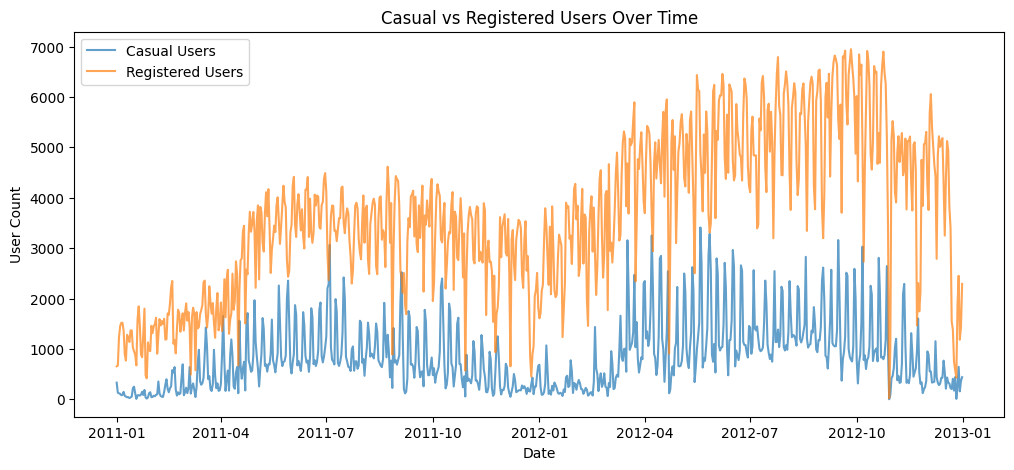

In [0]:
# Compare casual vs registered users over time
plt.figure(figsize=(12,5))
plt.plot(day_df['dteday'], day_df['casual'], label='Casual Users', alpha=0.7)
plt.plot(day_df['dteday'], day_df['registered'], label='Registered Users', alpha=0.7)
plt.legend()
plt.title("Casual vs Registered Users Over Time")
plt.xlabel("Date")
plt.ylabel("User Count")
plt.show()

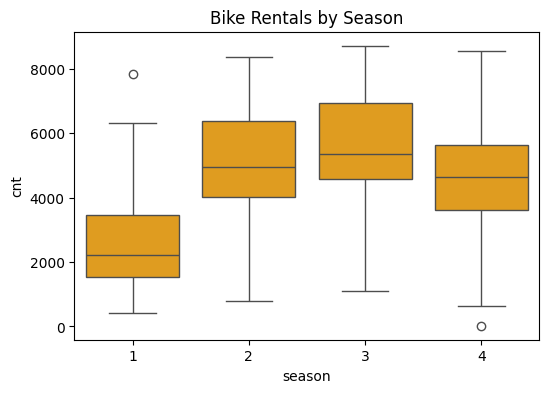

In [0]:
#Bike Rentals by Season
plt.figure(figsize=(6,4))
sns.boxplot(x="season", y="cnt", data=day_df,color='orange')
plt.title("Bike Rentals by Season")
plt.show()


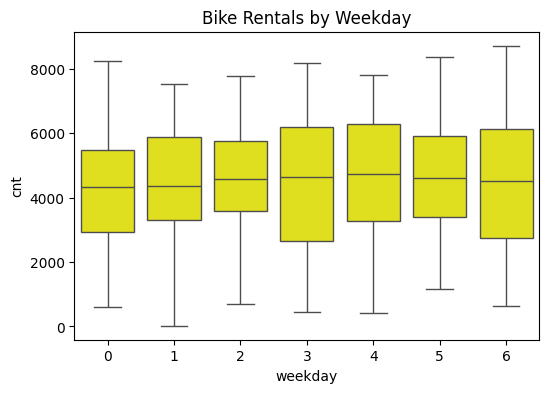

In [0]:
# Rentals by weekday
plt.figure(figsize=(6,4))
sns.boxplot(x="weekday", y="cnt", data=day_df, color = 'yellow')
plt.title("Bike Rentals by Weekday")
plt.show()

In [0]:
# Average rentals by month
monthly_avg = day_df.groupby('mnth')['cnt'].mean()
print("\nAverage rentals by month:")
print(monthly_avg)


Average rentals by month:
mnth
1     2176.338710
2     2655.298246
3     3692.258065
4     4484.900000
5     5349.774194
6     5772.366667
7     5563.677419
8     5664.419355
9     5766.516667
10    5199.225806
11    4247.183333
12    3403.806452
Name: cnt, dtype: float64



Average rentals per hour:
    hr         cnt
0    0   53.898072
1    1   33.375691
2    2   22.869930
3    3   11.727403
4    4    6.352941
5    5   19.889819
6    6   76.044138
7    7  212.064649
8    8  359.011004
9    9  219.309491
10  10  173.668501
11  11  208.143054
12  12  253.315934
13  13  253.661180
14  14  240.949246
15  15  251.233196
16  16  311.983562
17  17  461.452055
18  18  425.510989
19  19  311.523352
20  20  226.030220
21  21  172.314560
22  22  131.335165
23  23   87.831044


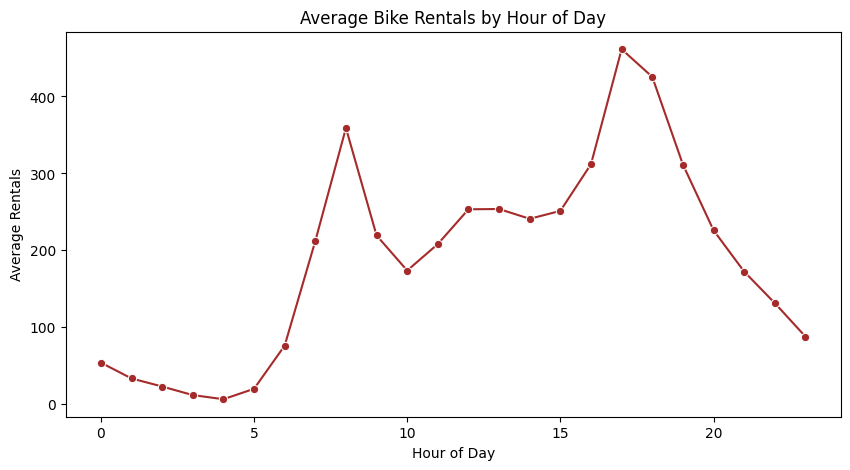

In [0]:
# Average rentals per hour (from hourly data)
hourly_avg = hour_df.groupby('hr')['cnt'].mean().reset_index()
print("\nAverage rentals per hour:")
print(hourly_avg)


plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=hourly_avg, marker='o', color = 'brown')
plt.title("Average Bike Rentals by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.show()

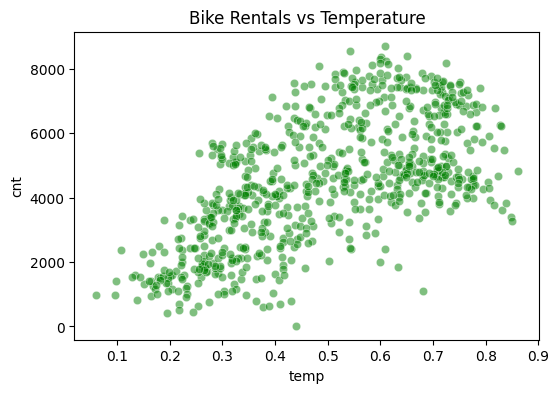

In [0]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="temp", y="cnt", data=day_df, alpha=0.5, color= 'green')
plt.title("Bike Rentals vs Temperature")
plt.show()

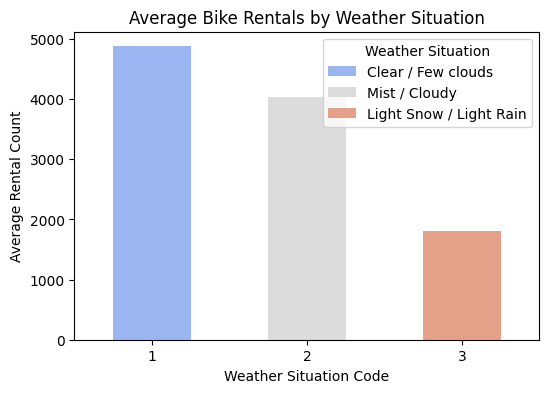

In [0]:
# Map numeric weather codes to descriptive labels
day_df['weathersit_label'] = day_df['weathersit'].map({
    1: "Clear / Few clouds",
    2: "Mist / Cloudy",
    3: "Light Snow / Light Rain",
    4: "Heavy Rain / Snow + Fog"
})

weather_avg = day_df.groupby(['weathersit', 'weathersit_label'])['cnt'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(
    x='weathersit', 
    y='cnt', 
    hue='weathersit_label', 
    data=weather_avg, 
    dodge=False, 
    palette="coolwarm",
    width=0.5  # reduce the width of the bars
)
plt.title("Average Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation Code")
plt.ylabel("Average Rental Count")
plt.legend(title="Weather Situation")
plt.show()


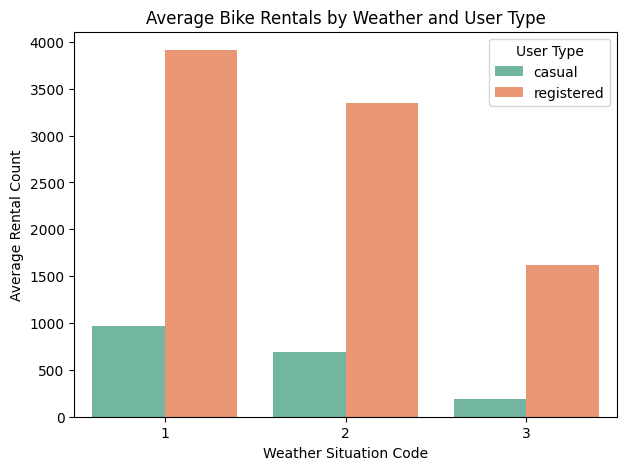

In [0]:
# Group by weather and user type
weather_user_avg = day_df.groupby('weathersit')[['casual', 'registered']].mean().reset_index()

# Melt into long format for seaborn
weather_user_melted = weather_user_avg.melt(
    id_vars='weathersit', 
    value_vars=['casual', 'registered'], 
    var_name='UserType', 
    value_name='AvgRentals'
)

# Map labels
weather_user_melted['weathersit_label'] = weather_user_melted['weathersit'].map({
    1: "Clear / Few clouds",
    2: "Mist / Cloudy",
    3: "Light Snow / Light Rain",
    4: "Heavy Rain / Snow + Fog"
})

# Plot
plt.figure(figsize=(7,5))
sns.barplot(
    x='weathersit', 
    y='AvgRentals', 
    hue='UserType', 
    data=weather_user_melted,
    palette="Set2"
)
plt.title("Average Bike Rentals by Weather and User Type")
plt.xlabel("Weather Situation Code")
plt.ylabel("Average Rental Count")
plt.legend(title="User Type")
plt.show()


In [0]:
print("\nSummary statistics:")
print(day_df[['cnt','casual','registered','temp','hum','windspeed']].describe())


Summary statistics:
               cnt       casual  ...         hum   windspeed
count   731.000000   731.000000  ...  731.000000  731.000000
mean   4504.348837   848.176471  ...    0.627894    0.190486
std    1937.211452   686.622488  ...    0.142429    0.077498
min      22.000000     2.000000  ...    0.000000    0.022392
25%    3152.000000   315.500000  ...    0.520000    0.134950
50%    4548.000000   713.000000  ...    0.626667    0.180975
75%    5956.000000  1096.000000  ...    0.730209    0.233214
max    8714.000000  3410.000000  ...    0.972500    0.507463

[8 rows x 6 columns]


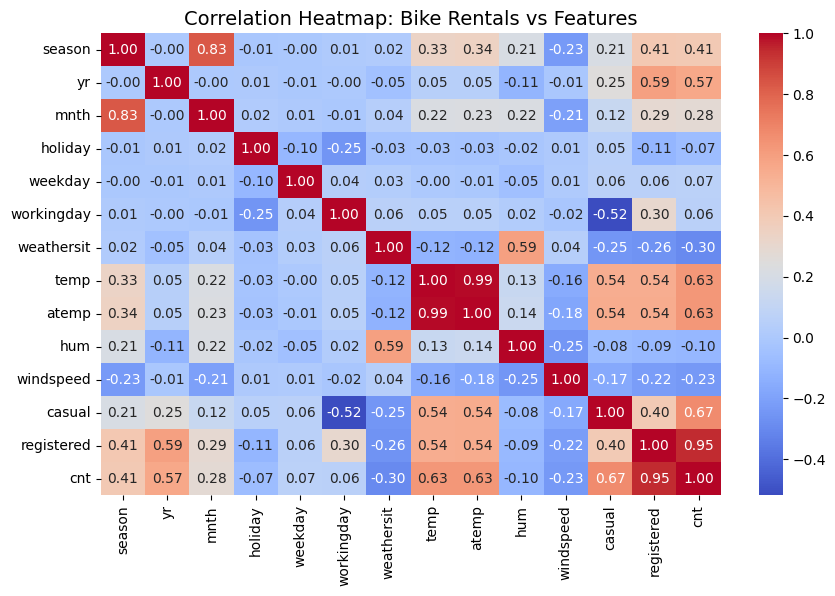

In [0]:
features = ['season', 'yr', 'mnth','holiday', 'weekday','workingday','weathersit','temp','atemp','hum', 'windspeed','casual','registered','cnt']
corr = day_data[features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap: Bike Rentals vs Features", fontsize=14)
plt.show()

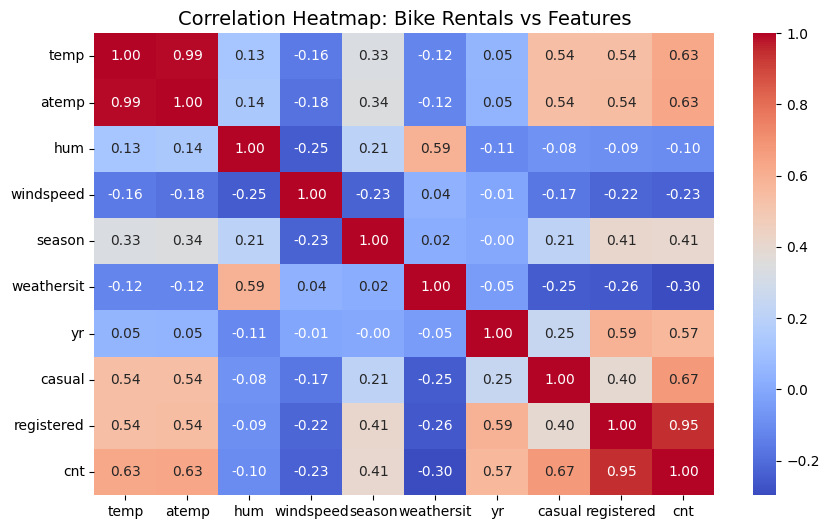

/home/spark-2f2b99ec-ad16-4acf-b635-c6/.ipykernel/2472/command-7313425643110953-1670769426:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_cnt.values, y=corr_with_cnt.index, palette="coolwarm")


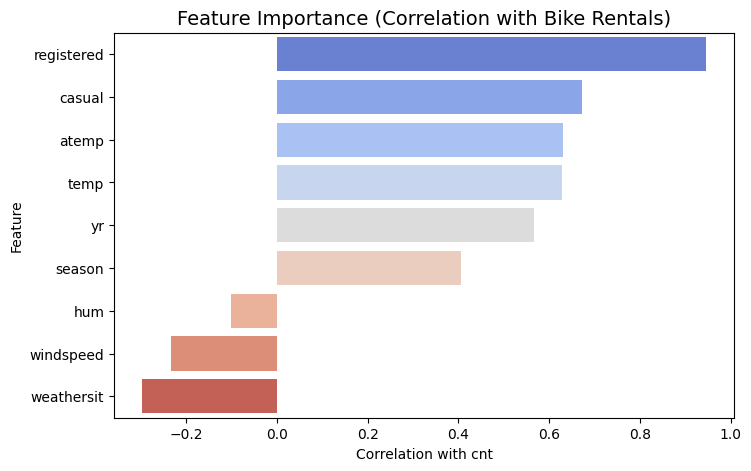

In [0]:
# Select relevant features
features = ["temp", "atemp", "hum", "windspeed", "season", "weathersit", "yr", "casual", "registered", "cnt"]

# Compute correlations
corr = day_data[features].corr()

# --- Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap: Bike Rentals vs Features", fontsize=14)
plt.show()

# --- Bar plot of feature importance ---
plt.figure(figsize=(8,5))
corr_with_cnt = corr["cnt"].drop("cnt").sort_values(ascending=False)
sns.barplot(x=corr_with_cnt.values, y=corr_with_cnt.index, palette="coolwarm")
plt.title("Feature Importance (Correlation with Bike Rentals)", fontsize=14)
plt.xlabel("Correlation with cnt")
plt.ylabel("Feature")
plt.show()